In [ ]:
#connect to drive
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive connected successfully!")

Mounted at /content/drive
Google Drive connected successfully!


In [ ]:
import os

base = '/content/drive/MyDrive/updated-dataset-20260102T042016Z-3-001'

files = os.listdir(base)

print("Files inside your dataset folder:")
for f in files:
    full_path = os.path.join(base, f)
    print(f"\n {f}")
    print(f"   Path: {full_path}")
    if os.path.isdir(full_path):
        inside = os.listdir(full_path)
        print(f"   Contains: {inside}")

Files inside your dataset folder:

 updated-dataset
   Path: /content/drive/MyDrive/updated-dataset-20260102T042016Z-3-001/updated-dataset
   Contains: ['valid', 'train']


In [ ]:
import os

print("Copying dataset from Drive to local storage...")
print("Please wait, this may take 2-5 minutes...\n")

# Exact path
source = '/content/drive/MyDrive/updated-dataset-20260102T042016Z-3-001/updated-dataset'
destination = '/content/dataset'

!cp -r "{source}" "{destination}"

print(" Dataset copied successfully!")

print("\n" + "="*50)
print("VERIFICATION:")
print("="*50)

train_path = '/content/dataset/train'
valid_path = '/content/dataset/valid'

if os.path.exists(train_path):
    print(f" Train folder: {train_path}")
    classes = os.listdir(train_path)
    print(f"   Classes: {classes}")

if os.path.exists(valid_path):
    print(f"Valid folder: {valid_path}")
    classes = os.listdir(valid_path)
    print(f"   Classes: {classes}")

print("\n Ready for training!")

Copying dataset from Drive to local storage...
Please wait, this may take 2-5 minutes...

 Dataset copied successfully!

VERIFICATION:
 Train folder: /content/dataset/train
   Classes: ['Non-Demented', 'Severe-Demented', 'Mild-Demented', 'Moderate-Demented', 'Very-Mild-Demented']
Valid folder: /content/dataset/valid
   Classes: ['Non-Demented', 'Severe-Demented', 'Mild-Demented', 'Moderate-Demented', 'Very-Mild-Demented']

 Ready for training!


In [ ]:
import os

train_path = '/content/dataset/train'
valid_path = '/content/dataset/valid'

print("="*50)
print("TRAINING DATA:")
print("="*50)

train_counts = {}
for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)
    count = len(os.listdir(class_path))
    train_counts[class_name] = count
    print(f"{class_name}: {count} images")

print(f"\nTotal Training Images: {sum(train_counts.values())}")

print("\n" + "="*50)
print("VALIDATION DATA:")
print("="*50)

valid_counts = {}
for class_name in os.listdir(valid_path):
    class_path = os.path.join(valid_path, class_name)
    count = len(os.listdir(class_path))
    valid_counts[class_name] = count
    print(f"{class_name}: {count} images")

print(f"\nTotal Validation Images: {sum(valid_counts.values())}")

TRAINING DATA:
Non-Demented: 1001 images
Severe-Demented: 1000 images
Mild-Demented: 1001 images
Moderate-Demented: 1001 images
Very-Mild-Demented: 1000 images

Total Training Images: 5003

VALIDATION DATA:
Non-Demented: 192 images
Severe-Demented: 4 images
Mild-Demented: 293 images
Moderate-Demented: 239 images
Very-Mild-Demented: 143 images

Total Validation Images: 871


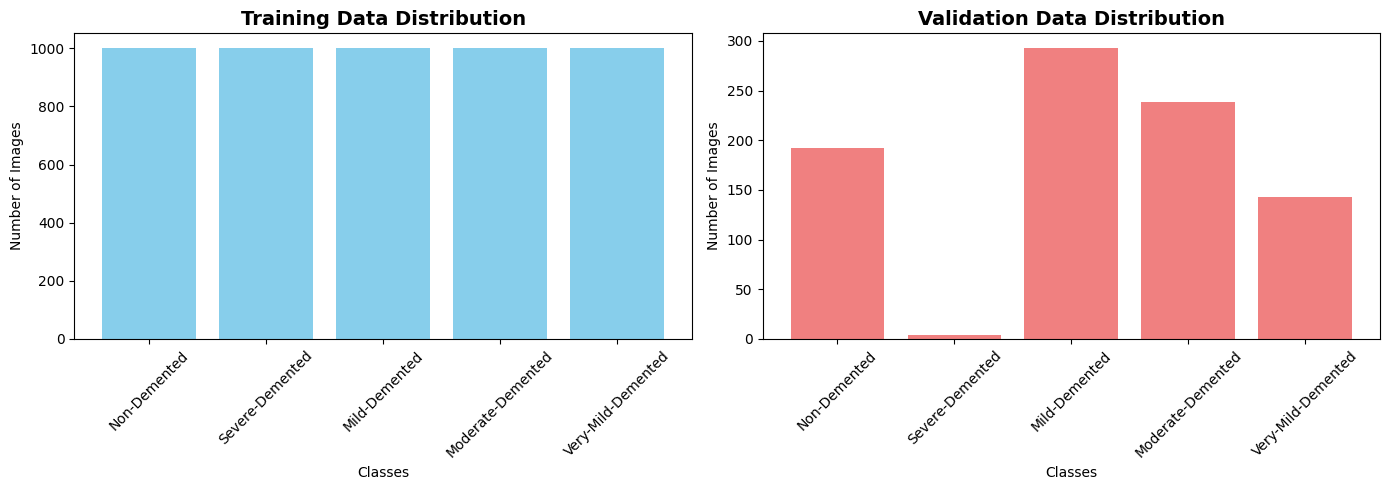


 Class Balance Ratio: 1.00
 Classes are reasonably balanced!


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(train_counts.keys(), train_counts.values(), color='skyblue')
ax1.set_title('Training Data Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Classes')
ax1.set_ylabel('Number of Images')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(valid_counts.keys(), valid_counts.values(), color='lightcoral')
ax2.set_title('Validation Data Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Classes')
ax2.set_ylabel('Number of Images')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

max_count = max(train_counts.values())
min_count = min(train_counts.values())
ratio = max_count / min_count

print(f"\n Class Balance Ratio: {ratio:.2f}")
if ratio > 3:
    print(" WARNING: Classes are imbalanced! Some classes have too few images.")
    print(" Solution: Use data augmentation or class weights")
else:
    print(" Classes are reasonably balanced!")

Training Set Sample Images:


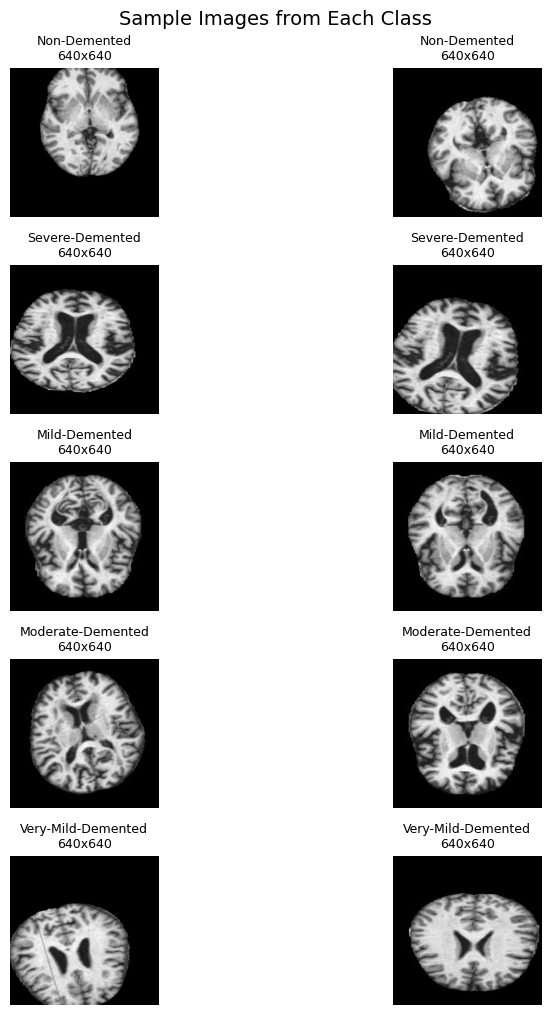

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random

def show_sample_images(folder_path, num_per_class=2):
    """Har class se kuch images dikhao"""

    classes = os.listdir(folder_path)

    fig, axes = plt.subplots(len(classes), num_per_class, figsize=(10, len(classes)*2))

    for i, class_name in enumerate(classes):
        class_path = os.path.join(folder_path, class_name)
        images = os.listdir(class_path)

        #select random images
        sample_images = random.sample(images, min(num_per_class, len(images)))

        for j, img_name in enumerate(sample_images):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if len(classes) > 1:
                ax = axes[i, j]
            else:
                ax = axes[j]

            ax.imshow(img)
            ax.set_title(f"{class_name}\n{img.shape[1]}x{img.shape[0]}", fontsize=9)
            ax.axis('off')

    plt.tight_layout()
    plt.suptitle('Sample Images from Each Class', fontsize=14, y=1.01)
    plt.show()

print("Training Set Sample Images:")
show_sample_images(train_path, num_per_class=2)

IMAGE SIZE ANALYSIS:
Width  - Min: 640px, Max: 640px, Avg: 640px
Height - Min: 640px, Max: 640px, Avg: 640px


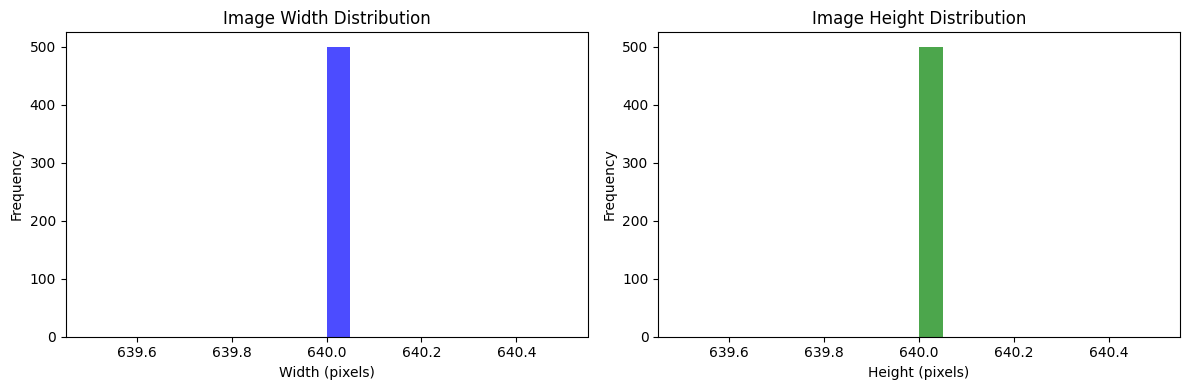


 Recommended CNN Input Size: 224x224


In [ ]:
import numpy as np

def check_image_sizes(folder_path, sample_size=100):


    widths = []
    heights = []

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        images = os.listdir(class_path)[:sample_size]

        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                h, w = img.shape[:2]
                widths.append(w)
                heights.append(h)

    return widths, heights

widths, heights = check_image_sizes(train_path)

print("="*50)
print("IMAGE SIZE ANALYSIS:")
print("="*50)
print(f"Width  - Min: {min(widths)}px, Max: {max(widths)}px, Avg: {np.mean(widths):.0f}px")
print(f"Height - Min: {min(heights)}px, Max: {max(heights)}px, Avg: {np.mean(heights):.0f}px")

# Histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(widths, bins=20, color='blue', alpha=0.7)
ax1.set_title('Image Width Distribution')
ax1.set_xlabel('Width (pixels)')
ax1.set_ylabel('Frequency')

ax2.hist(heights, bins=20, color='green', alpha=0.7)
ax2.set_title('Image Height Distribution')
ax2.set_xlabel('Height (pixels)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Recommendation
avg_size = int((np.mean(widths) + np.mean(heights)) / 2)
recommended = min(224, max(128, avg_size))
print(f"\n Recommended CNN Input Size: {recommended}x{recommended}")

In [ ]:
def check_corrupted_images(folder_path):

    issues = []
    total = 0

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            total += 1

            try:
                img = cv2.imread(img_path)
                if img is None:
                    issues.append(f"Cannot read: {img_path}")
                elif img.shape[0] < 32 or img.shape[1] < 32:
                    issues.append(f"Too small: {img_path}")
            except Exception as e:
                issues.append(f"Error: {img_path} - {e}")

    return issues, total

print("Checking image quality...")
issues, total = check_corrupted_images(train_path)

print("="*50)
print("DATA QUALITY REPORT:")
print("="*50)
print(f"Total images checked: {total}")
print(f"Issues found: {len(issues)}")

if issues:
    print("\n Problems:")
    for issue in issues[:10]:
        print(f"  - {issue}")
else:
    print("\n All images are good!")

Checking image quality...
DATA QUALITY REPORT:
Total images checked: 5003
Issues found: 3

 Problems:
  - Cannot read: /content/dataset/train/Non-Demented/desktop.ini
  - Cannot read: /content/dataset/train/Mild-Demented/desktop.ini
  - Cannot read: /content/dataset/train/Moderate-Demented/desktop.ini


In [ ]:
import os

def remove_desktop_ini(folder_path):
    count = 0
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)

        for file_name in os.listdir(class_path):
            if file_name == 'desktop.ini':
                file_path = os.path.join(class_path, file_name)
                os.remove(file_path)
                count += 1
                print(f"Deleted: {file_path}")

    return count

print("Removing desktop.ini files...")
train_removed = remove_desktop_ini('/content/dataset/train')
valid_removed = remove_desktop_ini('/content/dataset/valid')

print(f"\n Removed {train_removed + valid_removed} desktop.ini files")
print(" Dataset is now clean!")

Removing desktop.ini files...
Deleted: /content/dataset/train/Non-Demented/desktop.ini
Deleted: /content/dataset/train/Mild-Demented/desktop.ini
Deleted: /content/dataset/train/Moderate-Demented/desktop.ini
Deleted: /content/dataset/valid/Very-Mild-Demented/desktop.ini

 Removed 4 desktop.ini files
 Dataset is now clean!


In [ ]:

print("\nRechecking image quality...")
issues, total = check_corrupted_images(train_path)

print("="*50)
print("DATA QUALITY REPORT (AFTER CLEANUP):")
print("="*50)
print(f"Total images checked: {total}")
print(f"Issues found: {len(issues)}")

if issues:
    print("\n Remaining problems:")
    for issue in issues:
        print(f"  - {issue}")
else:
    print("\n No issues! ")


Rechecking image quality...
DATA QUALITY REPORT (AFTER CLEANUP):
Total images checked: 5000
Issues found: 0

 No issues! 


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

print(" Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

 Libraries imported successfully!
TensorFlow version: 2.19.0


In [ ]:
# Dataset paths
train_path = '/content/dataset/train'
valid_path = '/content/dataset/valid'

print(f"Train path exists: {os.path.exists(train_path)}")
print(f"Valid path exists: {os.path.exists(valid_path)}")

classes = os.listdir(train_path)
print(f"\nClasses: {classes}")
print(f"Number of classes: {len(classes)}")

Train path exists: True
Valid path exists: True

Classes: ['Non-Demented', 'Severe-Demented', 'Mild-Demented', 'Moderate-Demented', 'Very-Mild-Demented']
Number of classes: 5


In [ ]:
# Hyperparameters
IMG_SIZE = 227
BATCH_SIZE = 32
EPOCHS = 15
num_classes = 5
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")

print(f" Hyperparameters:")
print(f"  Epochs: {EPOCHS}")
print(f"  Number of Classes: {num_classes}")

  Image Size: 227x227
  Batch Size: 32
 Hyperparameters:
  Epochs: 15
  Number of Classes: 5


In [ ]:

# Load training data
train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

# Load validation data
valid_data = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False,
    seed=42
)

print(" Training and Validation data loaded successfully!")
print(f"Training batches: {len(train_data)}")
print(f"Validation batches: {len(valid_data)}")

Found 5000 files belonging to 5 classes.
Found 870 files belonging to 5 classes.
 Training and Validation data loaded successfully!
Training batches: 157
Validation batches: 28


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().prefetch(buffer_size=AUTOTUNE)
valid_data = valid_data.cache().prefetch(buffer_size=AUTOTUNE)

print(" Data optimized for faster training!")

 Data optimized for faster training!


In [ ]:
# AlexNet architecture
model = keras.Sequential([
    # Input layer
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1
    layers.Conv2D(96, kernel_size=11, strides=4, activation='relu', padding='valid'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=3, strides=2),

    # Block 2
    layers.Conv2D(256, kernel_size=5, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=3, strides=2),

    # Block 3
    layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),

    # Block 4
    layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),

    # Block 5
    layers.Conv2D(256, kernel_size=3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=3, strides=2),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

print(" AlexNet Model architecture created!")


 AlexNet Model architecture created!


In [ ]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,307,333 (222.42 MB)

 Trainable params: 58,304,581 (222.41 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [ ]:

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Model compiled successfully!")
print("\nModel is ready for training!")

 Model compiled successfully!

Model is ready for training!


In [ ]:
# Import callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Checkpoint to save best model
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/alexnet_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print(" Callbacks created!")
print("  Model will save to: /content/drive/MyDrive/alexnet_best.keras")
print("  Training will stop if no improvement for 10 epochs")

 Callbacks created!
  Model will save to: /content/drive/MyDrive/alexnet_best.keras
  Training will stop if no improvement for 10 epochs


In [ ]:
print("🚀 Starting training...")
print("This will take some time...\n")

# Train the model
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=EPOCHS
)

print("\n Training completed!")

🚀 Starting training...
This will take some time...

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 151ms/step - accuracy: 0.4633 - loss: 11.7427 - val_accuracy: 0.7299 - val_loss: 0.8510
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.7389 - loss: 0.7476 - val_accuracy: 0.6414 - val_loss: 1.4616
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.7740 - loss: 0.7620 - val_accuracy: 0.7701 - val_loss: 0.7428
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.8502 - loss: 0.5270 - val_accuracy: 0.1920 - val_loss: 17.4861
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.7248 - loss: 0.9282 - val_accuracy: 0.6529 - val_loss: 0.8022
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8586 - loss: 0.4792 - val_accuracy: 0.4701 - val_loss: 1.5212
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8826 - loss: 0.3519 - val_accuracy: 0.8310 - val_loss: 0.5120
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 8

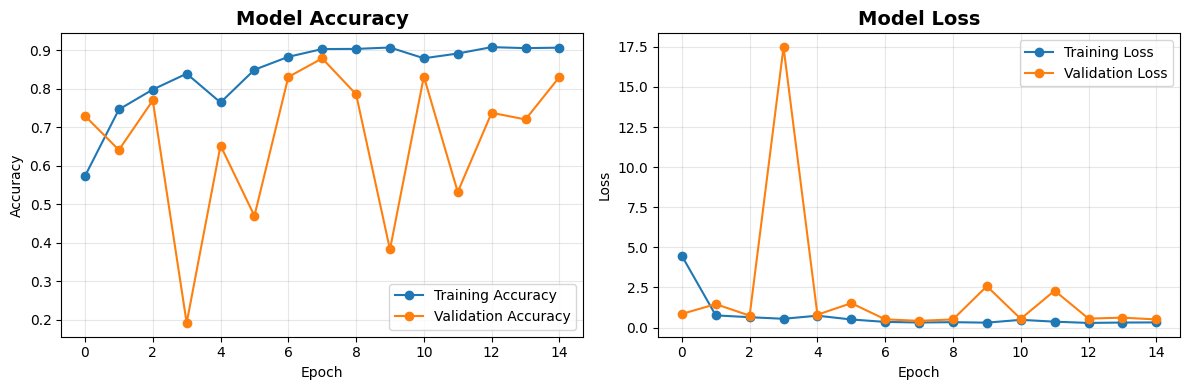

In [ ]:
# Accuracy & Loss graphs
plt.figure(figsize=(12, 4))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Final results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print("="*50)
print("FINAL RESULTS (Scratch CNN):")
print("="*50)
print(f"Training Accuracy:   {final_train_acc*100:.2f}%")
print(f"Validation Accuracy: {final_val_acc*100:.2f}%")
print("="*50)

FINAL RESULTS (Scratch CNN):
Training Accuracy:   90.72%
Validation Accuracy: 83.10%


In [ ]:
# Save the current trained model
model.save('/content/drive/MyDrive/alexnet_trained_model.keras')

print(" Model saved successfully!")
print(" Saved at: /content/drive/MyDrive/alexnet_trained_model.keras")

 Model saved successfully!
 Saved at: /content/drive/MyDrive/alexnet_trained_model.keras


In [ ]:
import os

# Check if file saved
if os.path.exists('/content/drive/MyDrive/alexnet_trained_model.keras'):
    print(" File confirmed! Model successfully saved.")
else:
    print(" File not found. Something went wrong.")

 File confirmed! Model successfully saved.


In [ ]:
# Load the saved model
best_model = keras.models.load_model('/content/drive/MyDrive/alexnet_trained_model.keras')

print(" Model loaded successfully!")
print("Ready for evaluation!")

 Model loaded successfully!
Ready for evaluation!


In [ ]:
# Test path use validation data for testing
test_path = '/content/drive/MyDrive/updated-dataset-20260102T042016Z-3-001/updated-dataset/valid'

# Load test data
test_data = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

print("Test data loaded!")
print(f"Test batches: {len(test_data)}")

Found 870 files belonging to 5 classes.
✅ Test data loaded!
Test batches: 28


In [ ]:
# Evaluate model on test data
print(" Evaluating model on test data...")
print("Please wait...\n")

test_loss, test_accuracy = best_model.evaluate(test_data)

print(f"\n{'='*50}")
print(f" FINAL TEST RESULTS:")
print(f"{'='*50}")
print(f"Test Accuracy:  {test_accuracy*100:.2f}%")
print(f"Test Loss:      {test_loss:.4f}")
print(f"{'='*50}")

 Evaluating model on test data...
Please wait...

28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - accuracy: 0.8747 - loss: 0.3877

 FINAL TEST RESULTS:
Test Accuracy:  83.10%
Test Loss:      0.5070


In [ ]:
print(" Generating predictions for confusion matrix...")

# Get predictions
y_pred = best_model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels
y_true = np.concatenate([y for x, y in test_data], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

print(f" Predictions generated!")
print(f"Total samples: {len(y_true_classes)}")
print(f"Correct predictions: {np.sum(y_pred_classes == y_true_classes)}")
print(f"Wrong predictions: {np.sum(y_pred_classes != y_true_classes)}")

 Generating predictions for confusion matrix...
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step
 Predictions generated!
Total samples: 870
Correct predictions: 723
Wrong predictions: 147


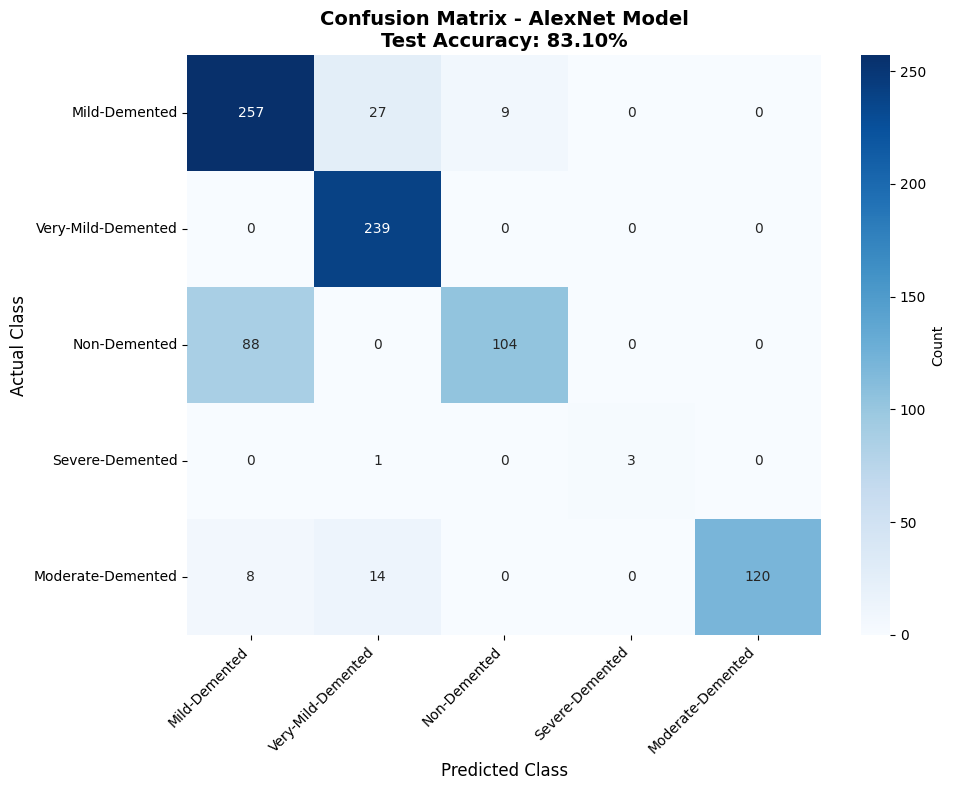

✅ Confusion Matrix generated!


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Class names
class_names = ['Mild-Demented', 'Very-Mild-Demented', 'Non-Demented',
               'Severe-Demented', 'Moderate-Demented']

# Generate confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - AlexNet Model\nTest Accuracy: 83.10%',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("✅ Confusion Matrix generated!")

In [ ]:
from sklearn.metrics import classification_report

print("="*60)
print("📋 DETAILED CLASSIFICATION REPORT")
print("="*60)

report = classification_report(y_true_classes, y_pred_classes,
                              target_names=class_names,
                              digits=4)
print(report)
print("="*60)

📋 DETAILED CLASSIFICATION REPORT
                    precision    recall  f1-score   support

     Mild-Demented     0.7280    0.8771    0.7957       293
Very-Mild-Demented     0.8505    1.0000    0.9192       239
      Non-Demented     0.9204    0.5417    0.6820       192
   Severe-Demented     1.0000    0.7500    0.8571         4
 Moderate-Demented     1.0000    0.8451    0.9160       142

          accuracy                         0.8310       870
         macro avg     0.8998    0.8028    0.8340       870
      weighted avg     0.8498    0.8310    0.8244       870



In [ ]:
print("\n" + "="*70)
print(" ALEXNET MODEL - FINAL PERFORMANCE SUMMARY")
print("="*70)

print("\n MODEL CONFIGURATION:")
print(f"  • Architecture:        AlexNet")
print(f"  • Image Size:          {IMG_SIZE}x{IMG_SIZE}")
print(f"  • Batch Size:          {BATCH_SIZE}")
print(f"  • Total Epochs:        {len(history.history['accuracy'])}")
print(f"  • Number of Classes:   {num_classes}")

print("\n TRAINING RESULTS:")
print(f"  • Final Training Accuracy:      {history.history['accuracy'][-1]*100:.2f}%")
print(f"  • Final Validation Accuracy:    {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"  • Best Validation Accuracy:     {max(history.history['val_accuracy'])*100:.2f}%")

print("\n TEST RESULTS:")
print(f"  • Test Accuracy:                {test_accuracy*100:.2f}%")
print(f"  • Test Loss:                    {test_loss:.4f}")
print(f"  • Correct Predictions:          {np.sum(y_pred_classes == y_true_classes)} / {len(y_true_classes)}")
print(f"  • Wrong Predictions:            {np.sum(y_pred_classes != y_true_classes)} / {len(y_true_classes)}")

print("\n MODEL SAVED AT:")
print(f"  • {'/content/drive/MyDrive/alexnet_trained_model.keras'}")

print("\n" + "="*70)
print(" ANALYSIS COMPLETE!")
print("="*70)


 ALEXNET MODEL - FINAL PERFORMANCE SUMMARY

 MODEL CONFIGURATION:
  • Architecture:        AlexNet
  • Image Size:          227x227
  • Batch Size:          32
  • Total Epochs:        15
  • Number of Classes:   5

 TRAINING RESULTS:
  • Final Training Accuracy:      90.72%
  • Final Validation Accuracy:    83.10%
  • Best Validation Accuracy:     87.93%

 TEST RESULTS:
  • Test Accuracy:                83.10%
  • Test Loss:                    0.5070
  • Correct Predictions:          723 / 870
  • Wrong Predictions:            147 / 870

 MODEL SAVED AT:
  • /content/drive/MyDrive/alexnet_trained_model.keras

 ANALYSIS COMPLETE!
